In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np

# COMPARANDO CATEGORIAS

Os gráficos deste capítulo visam ajudar nossos leitores a comparar valores entre categorias. Barras, linhas e pontos permitem que os leitores façam comparações tanto dentro de grupos quanto entre eles. Em alguns casos, queremos que o leitor visualize tanto os níveis quanto as variações, ou alguma outra combinação de variáveis; em outros, queremos concentrar sua atenção em uma comparação específica.

O desafio ao comparar dados categóricos é decidir o que queremos que o gráfico transmita. Existe um argumento ou uma narrativa principal? Há algum aspecto que possa ser identificado como a comparação mais importante que se deseja que o leitor faça? Como criadores de gráficos, precisamos priorizar a função que queremos que eles desempenhem. Ao incluir todas as barras ou pontos no gráfico, podemos acabar obscurecendo a mensagem que desejamos transmitir.

Este capítulo começa com o gráfico de barras. Assim como o gráfico de linhas que dará início ao próximo capítulo, o gráfico de barras é familiar à maioria dos leitores, o que o torna uma escolha conveniente para orientá-los ao comparar categorias ou observar mudanças ao longo do tempo. Ele também ocupa o topo do diagrama de hierarquia de percepção visual. Não é obrigatório fornecer sempre os valores exatos aos leitores, mas, quando o fazemos, o gráfico de barras é uma excelente escolha.



## GRÁFICOS DE UNIDADES, DE ISÓTIPOS E DE TIPO "WAFLE"

Gráficos de unidades exibem contagens de uma variável. Cada símbolo pode representar uma observação ou uma determinada quantidade de unidades. Por exemplo, se um símbolo representa dez carros e há dez ícones de carro, o leitor multiplica mentalmente os dois valores para obter um total de cem carros. Você pode utilizar gráficos de unidades para representar porcentagens, valores monetários ou qualquer outra quantidade discreta. É possível organizá-los em diferentes direções ou dividi-los em subcategorias utilizando cores ou contornos.

Outra vantagem desses gráficos é que eles podem propiciar uma conexão mais humana. Gráficos de barras, por exemplo, são abstratos e impessoais; eles condensam todas as pessoas refletidas naquele ponto de dados em uma única forma. Esses gráficos, por outro lado, oferecem a oportunidade de criar uma conexão com o tema ao lembrar aos leitores o número de pessoas representadas — especialmente quando cada ponto corresponde a uma pessoa.

Outra maneira simples de apresentar esses tipos de contagens discretas é simplesmente exibir os números. Em *The Big Book of Dashboards*, os autores Steve Wexler, Andy Cotgreave e Jeff Shaffer chamam isso de abordagem BAN: "Big-Ass Numbers" (Números Gigantescos). Os BANs podem funcionar melhor em dashboards, infográficos, postagens em redes sociais ou apresentações de slides, mas, pessoalmente, eu os utilizo com mais moderação em relatórios mais extensos.

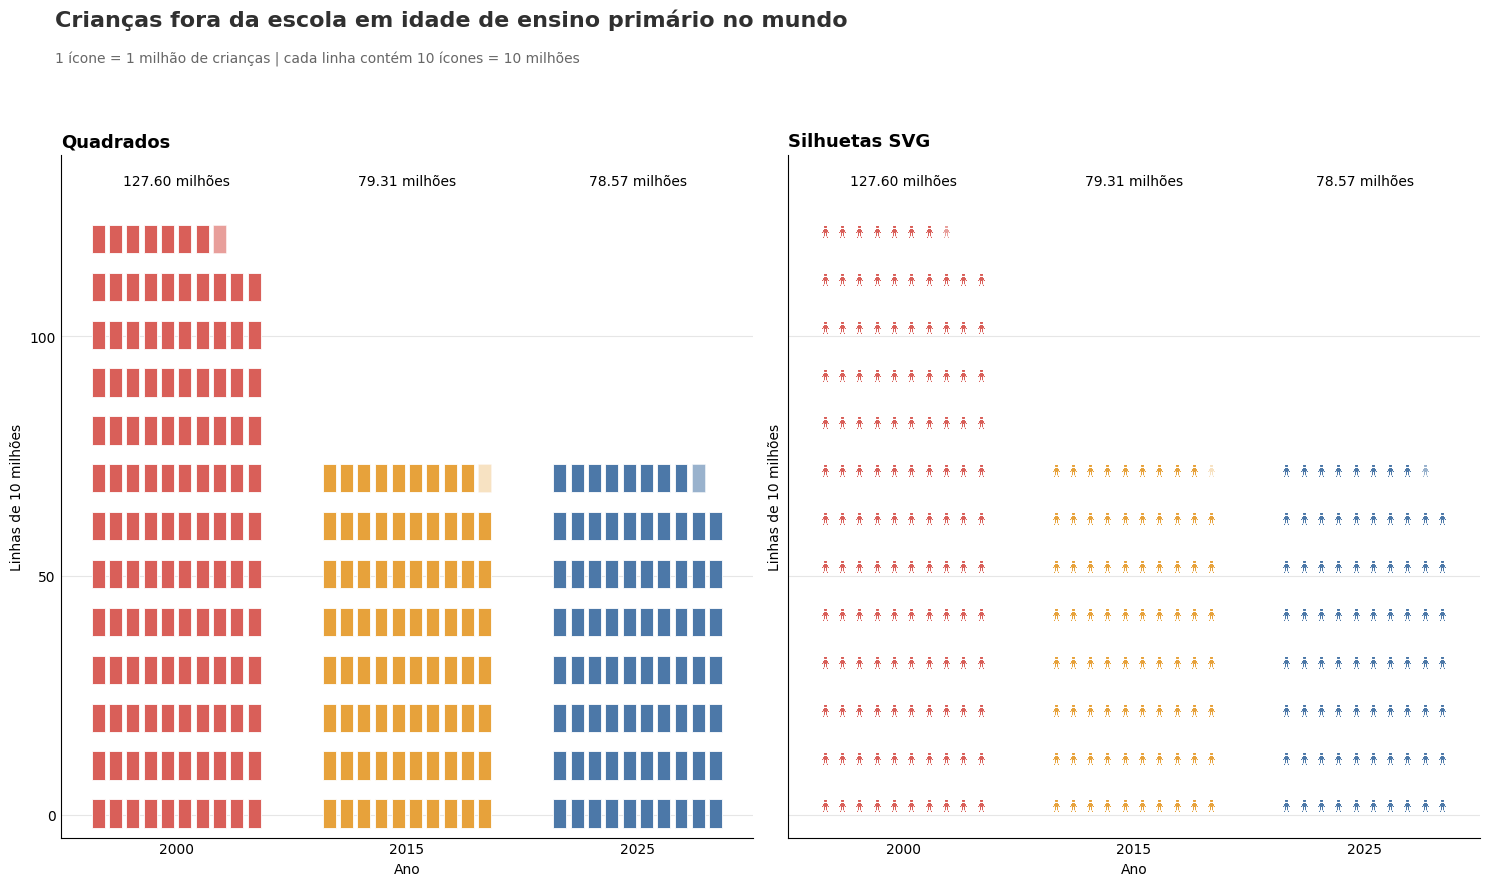

In [2]:
from io import BytesIO
from matplotlib.colors import to_rgb
from matplotlib.offsetbox import AnnotationBbox, OffsetImage
from matplotlib.patches import Rectangle

try:
    import cairosvg
except ModuleNotFoundError:
    import subprocess
    import sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "cairosvg"])
    import cairosvg

# Crianças fora da escola em idade de ensino primário, em milhões
anos = ["2000", "2015", "2025"]
valores_milhoes = [127.6, 79.31, 78.57]
cores = ["#D95F59", "#E7A23B", "#4C78A8"]

# Cada coluna representa um ano; cada linha contém 10 ícones = 10 milhões.
icones_por_linha = 10
espacamento_x = 0.075
espacamento_y = 0.95
max_linhas = int(np.ceil(max(valores_milhoes) / icones_por_linha))

fig, (ax_quadrados, ax_silhuetas) = plt.subplots(1, 2, figsize=(15, 9), sharey=True)

for indice, (ano, valor, cor) in enumerate(zip(anos, valores_milhoes, cores)):
    quantidade_inteira = int(valor)
    fracao = valor - quantidade_inteira
    quantidade_simbolos = quantidade_inteira + (1 if fracao > 0 else 0)
    x_centro = indice

    for simbolo in range(quantidade_simbolos):
        coluna = simbolo % icones_por_linha
        linha = simbolo // icones_por_linha
        x = x_centro + (coluna - 4.5) * espacamento_x
        y = linha * espacamento_y
        opacidade = 1.0 if simbolo < quantidade_inteira else fracao
        ax_quadrados.add_patch(Rectangle(
            (x - 0.028, y), 0.056, 0.56,
            facecolor=cor, edgecolor="white", linewidth=0.6, alpha=opacidade
        ))
    ax_quadrados.text(x_centro, max_linhas * espacamento_y + 0.35,
                      f"{valor:.2f} milhões", ha="center", va="bottom", fontsize=10)

ax_quadrados.set_title("Quadrados", loc="left", fontsize=13, weight="bold")
ax_quadrados.set_xlabel("Ano")
ax_quadrados.set_ylabel("Linhas de 10 milhões")
ax_quadrados.set_xticks(range(len(anos)), anos)
ax_quadrados.set_yticks(np.arange(0, max_linhas, 5) * espacamento_y + 0.25,
                        [str(linha * icones_por_linha) for linha in range(0, max_linhas, 5)])
ax_quadrados.set_xlim(-0.5, len(anos) - 0.5)
ax_quadrados.set_ylim(-0.2, max_linhas * espacamento_y + 1.0)
ax_quadrados.grid(axis="y", color="#E6E6E6", linewidth=0.8)

# Renderiza a silhueta SVG como PNG RGBA transparente e aplica a cor de cada ano.
with open("figures/silhueta_crianca.svg", "rb") as arquivo_svg:
    icone_png = cairosvg.svg2png(bytestring=arquivo_svg.read(), output_width=64, output_height=96)
icone_base = mpimg.imread(BytesIO(icone_png), format="png")

for indice, (ano, valor, cor) in enumerate(zip(anos, valores_milhoes, cores)):
    quantidade_inteira = int(valor)
    fracao = valor - quantidade_inteira
    quantidade_simbolos = quantidade_inteira + (1 if fracao > 0 else 0)
    x_centro = indice
    cor_rgb = np.array(to_rgb(cor))

    for simbolo in range(quantidade_simbolos):
        coluna = simbolo % icones_por_linha
        linha = simbolo // icones_por_linha
        x = x_centro + (coluna - 4.5) * espacamento_x
        y = linha * espacamento_y
        opacidade = 1.0 if simbolo < quantidade_inteira else fracao
        icone_colorido = np.zeros_like(icone_base)
        icone_colorido[..., :3] = cor_rgb
        icone_colorido[..., 3] = icone_base[..., 3] * opacidade
        ax_silhuetas.add_artist(AnnotationBbox(
            OffsetImage(icone_colorido, zoom=0.10), (x, y + 0.28),
            frameon=False, box_alignment=(0.5, 0), pad=0
        ))
    ax_silhuetas.text(x_centro, max_linhas * espacamento_y + 0.35,
                      f"{valor:.2f} milhões", ha="center", va="bottom", fontsize=10)

ax_silhuetas.set_title("Silhuetas SVG", loc="left", fontsize=13, weight="bold")
ax_silhuetas.set_xlabel("Ano")
ax_silhuetas.set_ylabel("Linhas de 10 milhões")
ax_silhuetas.set_xticks(range(len(anos)), anos)
ax_silhuetas.set_xlim(-0.5, len(anos) - 0.5)
ax_silhuetas.grid(axis="y", color="#E6E6E6", linewidth=0.8)

for ax in (ax_quadrados, ax_silhuetas):
    ax.set_axisbelow(True)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(length=0)

fig.suptitle("Crianças fora da escola em idade de ensino primário no mundo",
             x=0.04, ha="left", fontsize=16, weight="bold", color="#303030")
fig.text(0.04, 0.92,
         "1 ícone = 1 milhão de crianças | cada linha contém 10 ícones = 10 milhões",
         fontsize=10, color="#666666")
fig.tight_layout(rect=[0, 0, 1, 0.9])
plt.show()

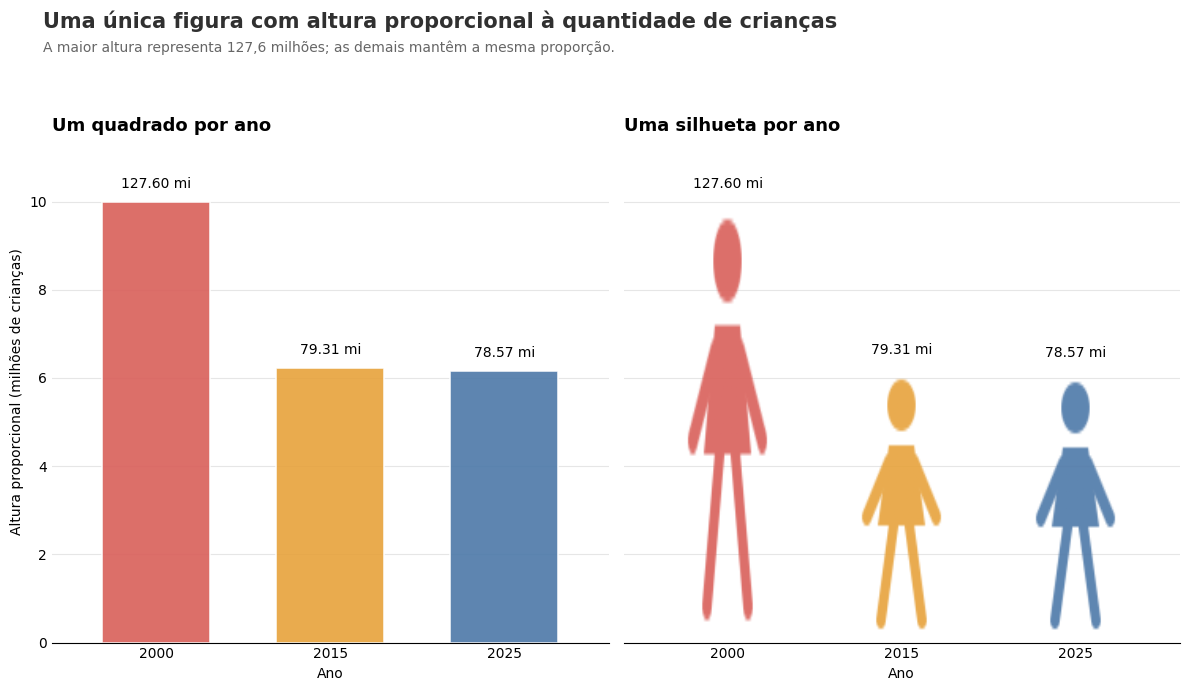

In [5]:
from io import BytesIO
from matplotlib.colors import to_rgb
from matplotlib.patches import Rectangle
import cairosvg

# Uma única figura por ano, com altura proporcional ao número de crianças.
altura_maxima = 10
alturas_proporcionais = np.array(valores_milhoes) / max(valores_milhoes) * altura_maxima
posicoes_anos = np.arange(len(anos))

fig, (ax_quadrado_unico, ax_silhueta_unica) = plt.subplots(1, 2, figsize=(12, 7), sharey=True)

for indice, (valor, altura, cor) in enumerate(zip(valores_milhoes, alturas_proporcionais, cores)):
    largura = 0.62
    ax_quadrado_unico.add_patch(Rectangle(
        (indice - largura / 2, 0), largura, altura,
        facecolor=cor, edgecolor="white", linewidth=1.2, alpha=0.9
    ))
    ax_quadrado_unico.text(indice, altura + 0.25, f"{valor:.2f} mi",
                           ha="center", va="bottom", fontsize=10)

ax_quadrado_unico.set_title("Um quadrado por ano", loc="left", fontsize=13, weight="bold")
ax_quadrado_unico.set_xlabel("Ano")
ax_quadrado_unico.set_ylabel("Altura proporcional (milhões de crianças)")
ax_quadrado_unico.set_xticks(posicoes_anos, anos)
ax_quadrado_unico.set_ylim(0, altura_maxima + 1.4)
ax_quadrado_unico.set_xlim(-0.6, len(anos) - 0.4)
ax_quadrado_unico.yaxis.grid(True, color="#E6E6E6", linewidth=0.8)

# Converte o SVG transparente; a largura fixa evita sobreposição entre os anos.
with open("figures/silhueta_crianca.svg", "rb") as arquivo_svg:
    icone_png = cairosvg.svg2png(bytestring=arquivo_svg.read(), output_width=64, output_height=96)
icone_base = mpimg.imread(BytesIO(icone_png), format="png")

for indice, (valor, altura, cor) in enumerate(zip(valores_milhoes, alturas_proporcionais, cores)):
    cor_rgb = np.array(to_rgb(cor))
    icone_colorido = np.zeros_like(icone_base)
    icone_colorido[..., :3] = cor_rgb
    icone_colorido[..., 3] = icone_base[..., 3] * 0.9
    largura = 0.58
    ax_silhueta_unica.imshow(
        icone_colorido,
        extent=(indice - largura / 2, indice + largura / 2, 0, altura),
        interpolation="bilinear", aspect="auto", zorder=3
    )
    ax_silhueta_unica.text(indice, altura + 0.25, f"{valor:.2f} mi",
                           ha="center", va="bottom", fontsize=10)

ax_silhueta_unica.set_title("Uma silhueta por ano", loc="left", fontsize=13, weight="bold")
ax_silhueta_unica.set_xlabel("Ano")
ax_silhueta_unica.set_xticks(posicoes_anos, anos)
ax_silhueta_unica.set_ylim(0, altura_maxima + 1.4)
ax_silhueta_unica.set_xlim(-0.6, len(anos) - 0.4)
ax_silhueta_unica.yaxis.grid(True, color="#E6E6E6", linewidth=0.8)

for ax in (ax_quadrado_unico, ax_silhueta_unica):
    ax.set_axisbelow(True)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(False)
    ax.tick_params(length=0)

fig.suptitle("Uma única figura com altura proporcional à quantidade de crianças",
             x=0.04, ha="left", fontsize=15, weight="bold", color="#303030")
fig.text(0.04, 0.92, "A maior altura representa 127,6 milhões; as demais mantêm a mesma proporção.",
         fontsize=10, color="#666666")
fig.tight_layout(rect=[0, 0, 1, 0.9])
plt.show()

### Gráficos isotype

Os gráficos Isotype são uma subclasse de gráficos de unidades que utilizam imagens ou ícones em vez de formas simples. O termo Isotype — sigla para *International System of Typographic Picture Education* (Sistema Internacional de Educação Visual Tipográfica) — foi cunhado pelo filósofo e economista político alemão Otto Neurath, por sua esposa Marie Neurath e pelo colaborador Gerd Arntz na década de 1920. Eles utilizavam o sistema Isotype para visualizar diversos tipos de dados, desde o número de trabalhadores em diferentes setores industriais e a densidade e distribuição populacional até a quantidade de máquinas utilizadas em fábricas específicas. Acreditavam que esse tipo de sistema visual ajudaria a comunicar questões demográficas, econômicas e ambientais a um público mais amplo, independentemente do nível de escolaridade das pessoas.

O gráfico abaixo é um exemplo clássico do trabalho deles. Cada símbolo representa uma quantidade diferente de trabalhadores (em casa ou na fábrica) e o volume de produção em libras. Alinhados ao longo de um único eixo vertical, é fácil perceber como os valores variam ao longo do tempo.

Podemos adotar a mesma abordagem com os dados sobre pobreza que temos utilizado neste capítulo. Observe que há mais de uma maneira de utilizar imagens Isotype nestes dois gráficos de taxas de pobreza extrema. A versão à esquerda utiliza ícones individuais para representar cada grupo de dez pontos percentuais (os ícones mais claros podem ou não ser incluídos). A versão à direita, essencialmente, dispõe os ícones sobre um gráfico de barras. Em ambos os casos, os ícones associam o tema e o conteúdo a uma imagem visual de reconhecimento imediato.

Em vez de alinhar os ícones em linhas ou em outro tipo de disposição, você também pode redimensioná-los de acordo com seus valores. No entanto, tenha cuidado, pois às vezes é difícil saber se os dados foram escalonados com base na altura, na largura ou na área. Isso pode não importar para todo público — aqui, fica claro que 47% é muito mais do que 14% —, mas, em situações em que a precisão é fundamental, essa abordagem de redimensionamento de ícones não é recomendada. Neste caso, a distância vertical representa os valores dos dados, mas a área do ícone à esquerda é cerca de 10 vezes maior que a do ícone à direita.

Esses gráficos baseados em ícones podem parecer atraentes e envolver os leitores — especialmente quando há poucos valores de dados —, mas podem dificultar a contagem e a comparação por parte do leitor. Em seu livro de 1914, *Graphic Methods for Presenting Facts* (Métodos Gráficos para Apresentação de Fatos), Willard Cope Bertin criticou essa abordagem: "Gráficos desse tipo, com figuras humanas representadas em tamanhos diferentes, geralmente são desenhados de modo que os dados sejam representados pela altura da figura. Tais gráficos são enganosos, pois a área da figura representada aumenta mais rapidamente do que a sua altura." Mais recentemente, Stephen Few, autor e instrutor na área de visualização de dados, escreveu que gráficos de unidades obrigam o leitor "a contar, ler os números ou tentar comparar as áreas formadas por cada um — tarefa que, na melhor das hipóteses, realizamos de forma precária".

No entanto, às vezes, as desvantagens da imprecisão e da compreensão mais lenta podem ser compensadas pelo fato de o gráfico ser memorável e envolvente para os leitores — uma constatação corroborada por pesquisas recentes. Em um estudo, os participantes demonstraram clara preferência por gráficos que utilizavam ícones empilhados em vez de barras simples. Verificou-se também que imagens posicionadas ao fundo ou adicionadas ao gráfico sem representar dados distraem o leitor; portanto, se você optar por utilizar esse tipo de ícone ou imagem em seu trabalho, certifique-se de empregá-los apenas para codificar os dados, e não como mera decoração.

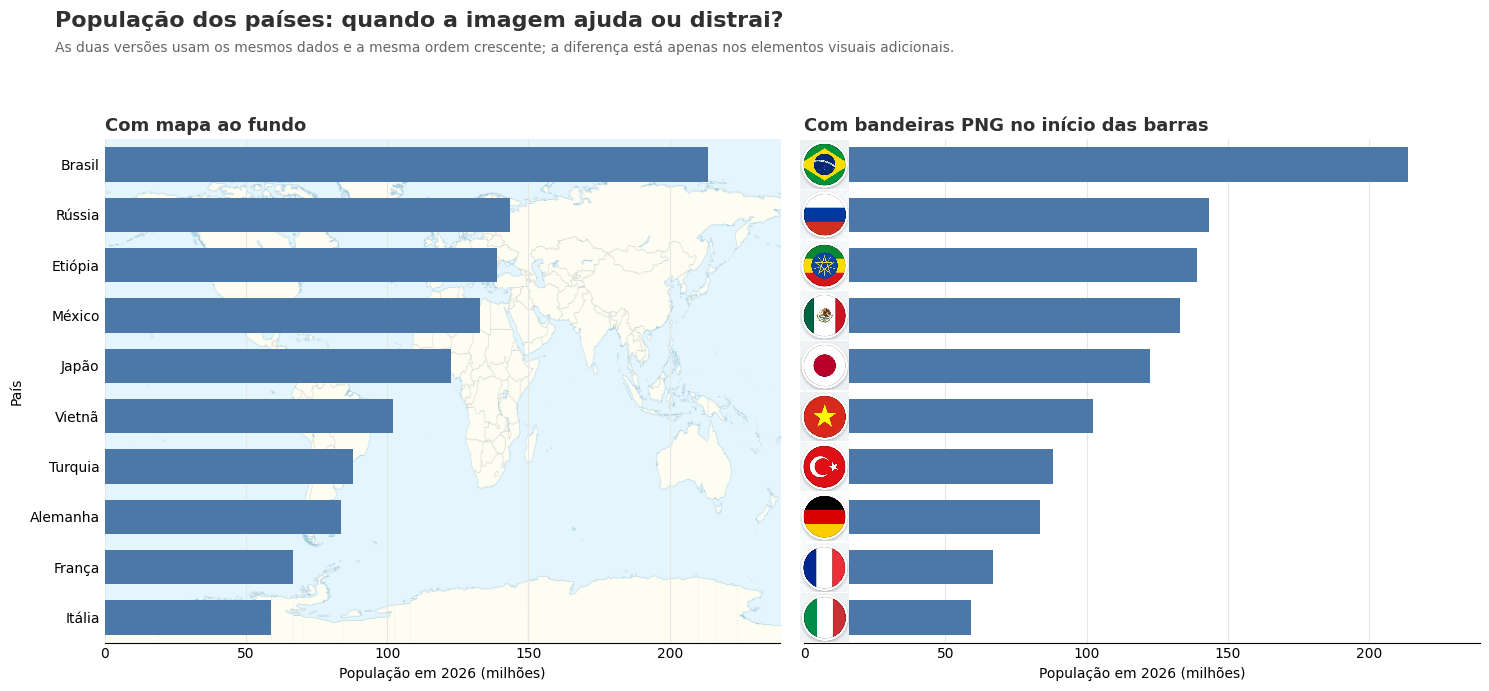

In [21]:
from matplotlib.offsetbox import AnnotationBbox, OffsetImage
from matplotlib.patches import Polygon
from matplotlib.transforms import blended_transform_factory

# População dos países selecionados, ordenada do menor para o maior valor.
populacao = pd.read_csv("../Data/populao-por-pas--2026.csv", encoding="utf-8-sig")
populacao["População_milhões"] = populacao["População (2026)"].astype(float) / 1_000_000
populacao = populacao.sort_values("População_milhões").reset_index(drop=True)

GRAFITE = "#303030"
AZUL_BARRA = "#4C78A8"
PAISES = populacao["País"].tolist()
VALORES = populacao["População_milhões"].to_numpy()
posicoes = np.arange(len(populacao))
limite_x = VALORES.max() * 1.12

fig, (ax_mapa, ax_bandeiras) = plt.subplots(1, 2, figsize=(15, 7), sharey=True)

# Mapa real como plano de fundo, com baixa transparência e atrás das barras.
mapa_mundo = mpimg.imread("../Data/World_location_map_(equirectangular_180).svg.webp")
ax_mapa.imshow(
    mapa_mundo,
    extent=(0, limite_x, -0.5, len(populacao) - 0.5),
    aspect="auto",
    alpha=0.50,
    zorder=0,
)
ax_mapa.barh(posicoes, VALORES, color=AZUL_BARRA, height=0.68, zorder=3)
ax_mapa.set_title("Com mapa ao fundo", loc="left", fontsize=13, weight="bold", color=GRAFITE)
ax_mapa.set_xlabel("População em 2026 (milhões)")
ax_mapa.set_ylabel("País")
ax_mapa.set_yticks(posicoes, PAISES)
ax_mapa.set_xlim(0, limite_x)
ax_mapa.grid(axis="x", color="#E6E6E6", linewidth=0.8, zorder=1)

# Bandeiras PNG posicionadas no início das barras.
transform_bandeira = blended_transform_factory(ax_bandeiras.transAxes, ax_bandeiras.transData)
nomes_arquivos = {pais: "Italia" if pais == "Itália" else pais for pais in PAISES}
for pais, y in zip(PAISES, posicoes):
    imagem_bandeira = mpimg.imread(f"../Data/{nomes_arquivos[pais]}.png")
    ax_bandeiras.add_artist(AnnotationBbox(
        OffsetImage(imagem_bandeira, zoom=0.16),
        (0.03, y),
        xycoords=transform_bandeira,
        box_alignment=(0.5, 0.5),
        frameon=False,
        pad=0,
        zorder=5,
    ))

ax_bandeiras.barh(posicoes, VALORES, color=AZUL_BARRA, height=0.68, zorder=3)
ax_bandeiras.set_title("Com bandeiras PNG no início das barras", loc="left", fontsize=13,
                       weight="bold", color=GRAFITE)
ax_bandeiras.set_xlabel("População em 2026 (milhões)")
ax_bandeiras.set_yticks(posicoes, PAISES)
ax_bandeiras.set_xlim(0, limite_x)
ax_bandeiras.grid(axis="x", color="#E6E6E6", linewidth=0.8, zorder=1)

for ax in (ax_mapa, ax_bandeiras):
    ax.set_axisbelow(True)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(False)
    ax.tick_params(length=0)

fig.suptitle("População dos países: quando a imagem ajuda ou distrai?",
             x=0.04, ha="left", fontsize=16, weight="bold", color=GRAFITE)
fig.text(0.04, 0.92,
         "As duas versões usam os mesmos dados e a mesma ordem crescente; a diferença está apenas nos elementos visuais adicionais.",
         fontsize=10, color="#666666")
fig.tight_layout(rect=[0, 0, 1, 0.9])
plt.show()

O gráfico à esquerda, que apresenta a população de dez países, tem como fundo um mapa-múndi — um elemento decorativo supérfluo e que causa distração. Já o gráfico à direita utiliza ícones de bandeiras para acrescentar detalhes de identificação e certo apelo visual a um tipo de gráfico convencional.

Outras pesquisas sugerem que as visualizações por unidades são intuitivas e flexíveis, oferecendo aos leitores uma maneira de assimilar a visualização gradualmente. Alguns estudos apontam que "as visualizações por unidades são especialmente úteis quando se deseja que os leitores compreendam um item de dados específico e identifiquem seu valor (por exemplo, uma unidade, uma pessoa, uma moeda, uma região, etc.)". No entanto, o excesso de dados e de unidades pode resultar em uma visualização poluída, que obscurece pontos de dados individuais ou o argumento central.

### Gráficos de wafle

Gráficos de waffle são outra subclasse de gráficos de unidades. Eles são especialmente adequados para visualizar relações de parte para o todo. Os gráficos de waffle são organizados em uma grade de 10 × 10, na qual cada célula colorida representa um ponto percentual. Você pode utilizar vários gráficos de waffle para exibir porcentagens distintas; assim, o gráfico não apenas mostra relações de parte para o todo, mas também permite que o leitor faça comparações entre as categorias.

Ao criar gráficos de unidades ou do tipo *waffle* — especialmente ao utilizar ícones —, leve em conta o seu público e a possibilidade de que certos símbolos não representem adequadamente o conteúdo. Se você estiver visualizando taxas de mortalidade infantil em diferentes países, por exemplo, o ícone de um bebê não é apropriado. O uso de ícones de homens para representar contagens de pessoas pode acabar excluindo as mulheres do seu conjunto de dados. Como alternativa, se quiser mensurar os diferentes tipos de brócolis em sua horta, basta alinhar as imagens, tal como neste projeto divertido de Zachary Stensell, mostrado acima.

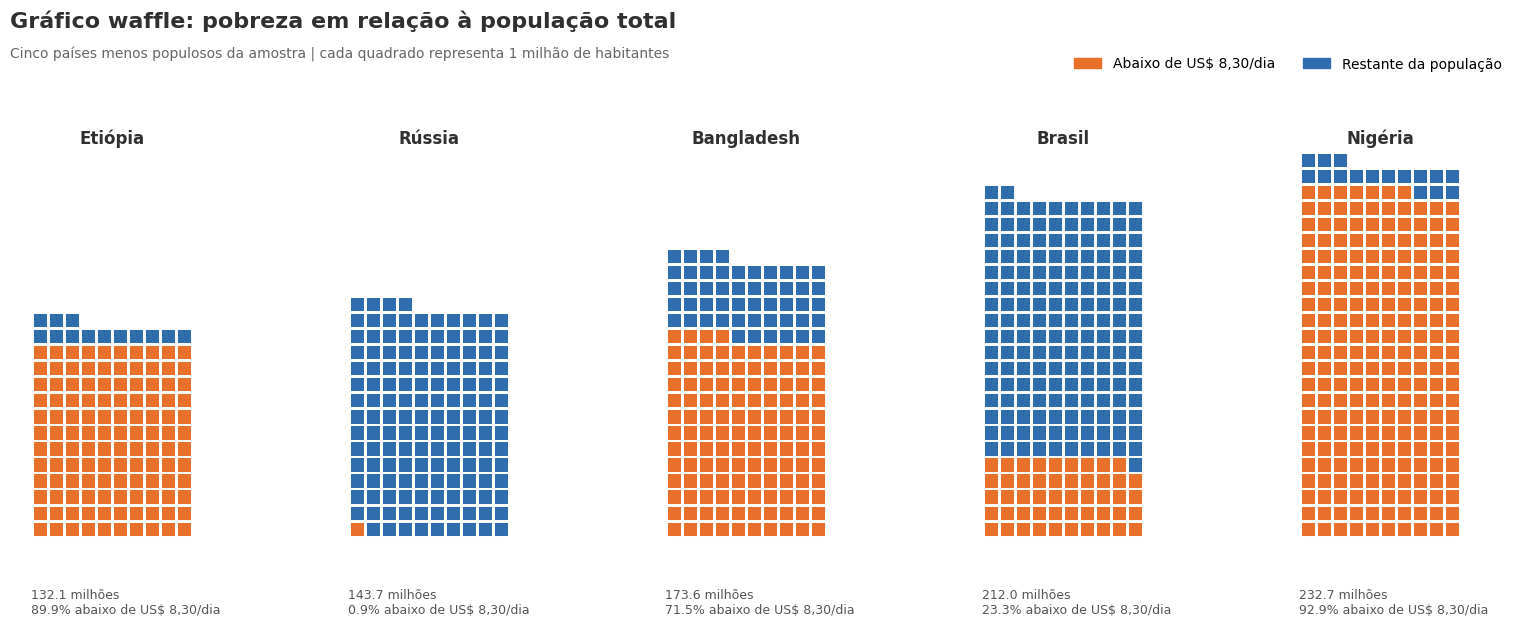

In [25]:
# Gráfico waffle: cinco países menos populosos e pobreza abaixo de US$ 8,30/dia
pobreza = pd.read_csv(
    "../Data/marimekko_pobreza_top10_usd830.csv",
    sep="\t",
    encoding="utf-16",
)
pobreza = pobreza.rename(columns={
    "país": "País",
    "população total": "População_total",
    "proporção de pessoas com renda inferior a US$ 8,30 por dia": "Proporção_pobreza",
})
pobreza["População_total"] = pd.to_numeric(pobreza["População_total"], errors="raise")
pobreza["Proporção_pobreza"] = pd.to_numeric(pobreza["Proporção_pobreza"], errors="raise")
pobreza = pobreza.sort_values("População_total").head(5).reset_index(drop=True)

LARANJA = "#E8702A"
AZUL = "#2F6DAE"
QUADRADOS_POR_LINHA = 10

fig, eixos = plt.subplots(1, len(pobreza), figsize=(16, 7), sharey=True)
for eixo, (_, linha) in zip(eixos, pobreza.iterrows()):
    total_milhoes = linha["População_total"] / 1_000_000
    total_quadrados = int(np.ceil(total_milhoes))
    quadrados_laranja = int(np.rint(total_quadrados * linha["Proporção_pobreza"]))
    quadrados_azuis = total_quadrados - quadrados_laranja

    cores_quadrados = [LARANJA] * quadrados_laranja + [AZUL] * quadrados_azuis
    for indice, cor in enumerate(cores_quadrados):
        coluna = indice % QUADRADOS_POR_LINHA
        linha_grid = indice // QUADRADOS_POR_LINHA
        eixo.add_patch(Rectangle(
            (coluna, linha_grid), 0.88, 0.88,
            facecolor=cor, edgecolor="white", linewidth=0.7,
        ))

    eixo.set_title(linha["País"], fontsize=12, weight="bold", color=GRAFITE)
    eixo.text(
        0, -0.08,
        f"{total_milhoes:.1f} milhões\n{linha['Proporção_pobreza']:.1%} abaixo de US$ 8,30/dia",
        transform=eixo.transAxes, ha="left", va="top", fontsize=9, color="#555555",
    )
    eixo.set_xlim(-0.1, QUADRADOS_POR_LINHA)
    eixo.set_ylim(-1.25, np.ceil(total_quadrados / QUADRADOS_POR_LINHA))
    eixo.set_aspect("equal")
    eixo.axis("off")

fig.suptitle(
    "Gráfico waffle: pobreza em relação à população total",
    x=0.04, ha="left", fontsize=16, weight="bold", color=GRAFITE,
)
fig.text(
    0.04, 0.91,
    "Cinco países menos populosos da amostra | cada quadrado representa 1 milhão de habitantes",
    fontsize=10, color="#666666",
)
fig.legend(
    handles=[Rectangle((0, 0), 1, 1, color=LARANJA), Rectangle((0, 0), 1, 1, color=AZUL)],
    labels=["Abaixo de US$ 8,30/dia", "Restante da população"],
    frameon=False, loc="upper right", bbox_to_anchor=(0.98, 0.93), ncol=2,
)
fig.tight_layout(rect=[0, 0.08, 1, 0.88])
plt.show()